In [3]:
dT_heat_exchanger = 8
T_cond = 70
T_evap = -7-dT_heat_exchanger
wf="R290"
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
from HPS_regular import RegularHeatPumpStudy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Purpose
to create a scatter plot of the gas states (pressure and temperature) that can occure during normal operation of a propane heat pump with the evaporator limits of -20°C to +20°C, and a superheating of 5K. The plot should be created using matplotlib and the data should be generated using the HeatPumpStudy.py module. The plot should include the following features:
- The x-axis should represent the pressure in bar and the y-axis should represent the temperature in °C.
- The plot should include a title and axis labels.
- The plot should include a grid.
- The plot should include a legend.
- The gas state should be measured at the compressor inlet.

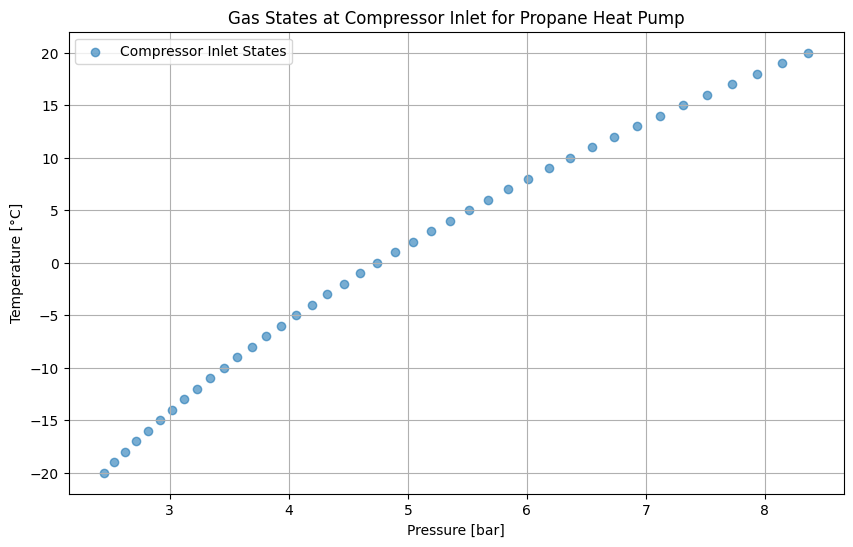

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Create data points for different evaporator temperatures
T_evap_range = np.linspace(-20, 20, 41)  # -20°C to +20°C in 1°C steps
dT_superheat = 5  # Constant superheat of 5K

# Lists to store the results
pressures = []
temperatures = []

# Calculate states for each evaporator temperature
for T_e in T_evap_range:
    try:
        # Create heat pump study instance with current evaporator temperature
        # T_e is the evaporator temperature, and we add superheat to it
        hps = RegularHeatPumpStudy(working_fluid=wf)
        hps.setup_network()  # Ensure fresh network for each point
        hps.set_boundary_conditions(T_cond=T_cond, T_evap=T_e)
        hps.solve(mode='design')
        
        # Get the connection state at compressor inlet
        conn = hps.conn['evaporator-compressor']
        
        # Store pressure (already in bar) and temperature (already in °C)
        pressures.append(conn.p.val)
        temperatures.append(conn.T.val)  
    except Exception as e:
        print(f'Failed at T_evap = {T_e}°C: {str(e)}')
        continue

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pressures, temperatures, alpha=0.6, label='Compressor Inlet States')

# Customize the plot
plt.title('Gas States at Compressor Inlet for Propane Heat Pump')
plt.xlabel('Pressure [bar]')
plt.ylabel('Temperature [°C]')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()